## General

Target output for this table includes:
- Median energy ± 68% containment
  - for proton, iron, and mixed composition
  - for each tier
  - for each zenith bin
- Systematic uncertainties for mixed composition
  - requires median energy values from every year, every particle interaction model, every composition assumption

## Set-Up

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtran
import matplotlib.gridspec as gridspec

In [2]:
# Define a function for weighted quantiles
def weighted_quantiles(values, weights, quantiles=[0.5]):
    if len(values) == 0:
        return 0
    else:
        i = np.argsort(values)
        c = np.cumsum(weights[i])
        return values[i[np.searchsorted(c, np.asarray(quantiles) * c[-1])]]

In [3]:
# Number of protons for different compositions
Z = {
    'proton': 1,
    'helium': 2,
    'nitrogen': 7,
    'oxygen': 8,
    'aluminum': 13,
    'iron': 26
}

# Zenith split
it_split = 38.

## Full-Sky

### Median Values and Statistical Uncertainties

In [4]:
year = 2012
model = 'SIBYLL2.1'

In [5]:
# Load in the SIBYLL2.1 particle sims - note that these will also be your variable names
KEYS = ['energy', 'particle_type', 'hits', 'reco_pass', 'showerplane_zen', 'laputop_zen', 'Hweights', 'Gweights']

for key in KEYS:
    sim_file = f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'
    with open(sim_file, 'rb') as file:
        globals()[key] = np.load(file)

In [6]:
# Cuts for different compositions
IT_COMPS = {
    'proton': particle_type == 2.21200000e+03,
    'helium': particle_type == 1.00002004e+09,
    'oxygen': particle_type == 1.00008016e+09,
    'iron'  : particle_type == 1.00026056e+09
}

# Directional reconstruction cuts
plane_cut   = (showerplane_zen < np.radians(55))
laputop_cut = (laputop_zen < np.radians(55))
reco_cut    = (reco_pass == 1)

# Energy tier cuts
offset = np.ceil((year - 2011)/2)
TIERS = {
    'Tier 1': (3 <= hits) * (hits < 5),
    'Tier 2': (5 <= hits) * (hits < 10 - offset),
    'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
    'Tier 4': (17 - offset <= hits)
}

# Weights
it_weights = Gweights

In [7]:
ref_medians = {}

for tier, tier_cut in TIERS.items():
    
    # Print Tier for table
    print(tier)
    print('--------------------------')
    
    for comp in ['proton','iron','all']:

        if tier == 'Tier 1':
            combined_cut = tier_cut * plane_cut
        else:
            combined_cut = tier_cut * laputop_cut * reco_cut

        if comp != 'all':
            combined_cut *= IT_COMPS[comp]
       
        # Print median energy and its first sigma
        median, sigl, sigr = weighted_quantiles(energy[combined_cut], it_weights[combined_cut], quantiles=[.5,.16,.84]) / 1e6
        print(f'    {comp:<8} {median:.2f} -{(median-sigl):.2f} +{(sigr-median):.2f} PeV')

        # Save values for later reference
        if comp == 'all':
            ref_medians[tier] = [median, median-sigl, sigr-median]
        
    print()

Tier 1
--------------------------
    proton   0.27 -0.13 +0.28 PeV
    iron     0.39 -0.19 +0.40 PeV
    all      0.30 -0.14 +0.31 PeV

Tier 2
--------------------------
    proton   0.81 -0.42 +0.84 PeV
    iron     1.15 -0.54 +1.23 PeV
    all      0.90 -0.47 +0.97 PeV

Tier 3
--------------------------
    proton   2.01 -0.86 +1.87 PeV
    iron     2.83 -1.25 +3.20 PeV
    all      2.28 -1.02 +2.20 PeV

Tier 4
--------------------------
    proton   5.79 -2.34 +6.53 PeV
    iron     8.73 -4.12 +13.68 PeV
    all      6.55 -2.76 +8.34 PeV



### Systematic Uncertainties

In [8]:
SIMS = {
    'EPOS-LHC': [2012, 2018],
    'QGSJET-II-04': [2012, 2018],
    'SIBYLL2.1': [2012, 2015],
    'SIBYLL2.3': [2012],
    'SIBYLL2.3d': [2018]
}

In [9]:
# Store median values for energy in dictionary
median_dict = {f'Tier {i}':[] for i in range(1,5)}

In [10]:
for model, year_list in SIMS.items():

    for year in year_list:

        # Load target simulation
        for key in KEYS:
            sim_file = f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'
            with open(sim_file, 'rb') as file:
                globals()[key] = np.load(file)

        # Weights
        WEIGHTS = {
            'GSF': Gweights,
            'H4a': Hweights
        }

        # Directional reconstruction cuts
        plane_cut   = (showerplane_zen < np.radians(55))
        laputop_cut = (laputop_zen < np.radians(55))
        reco_cut    = (reco_pass == 1)

        # Energy tier cuts
        offset = int(np.ceil((year - 2011)/2))
        TIERS = {
            'Tier 1': (3 <= hits) * (hits < 5),
            'Tier 2': (5 <= hits) * (hits < 10 - offset),
            'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
            'Tier 4': (17 - offset <= hits)}
        if year >= 2015:
            TIERS.pop('Tier 1', None)
            TIERS.pop('Tier 2', None)

        for tier, tier_cut in TIERS.items():

            if tier == 'Tier 1':
                combined_cut = tier_cut * plane_cut
            else:
                combined_cut = tier_cut * laputop_cut * reco_cut

            for weight_name, it_weights in WEIGHTS.items():
                
                median_dict[tier] += [weighted_quantiles(energy[combined_cut], it_weights[combined_cut])[0] / 1e6]

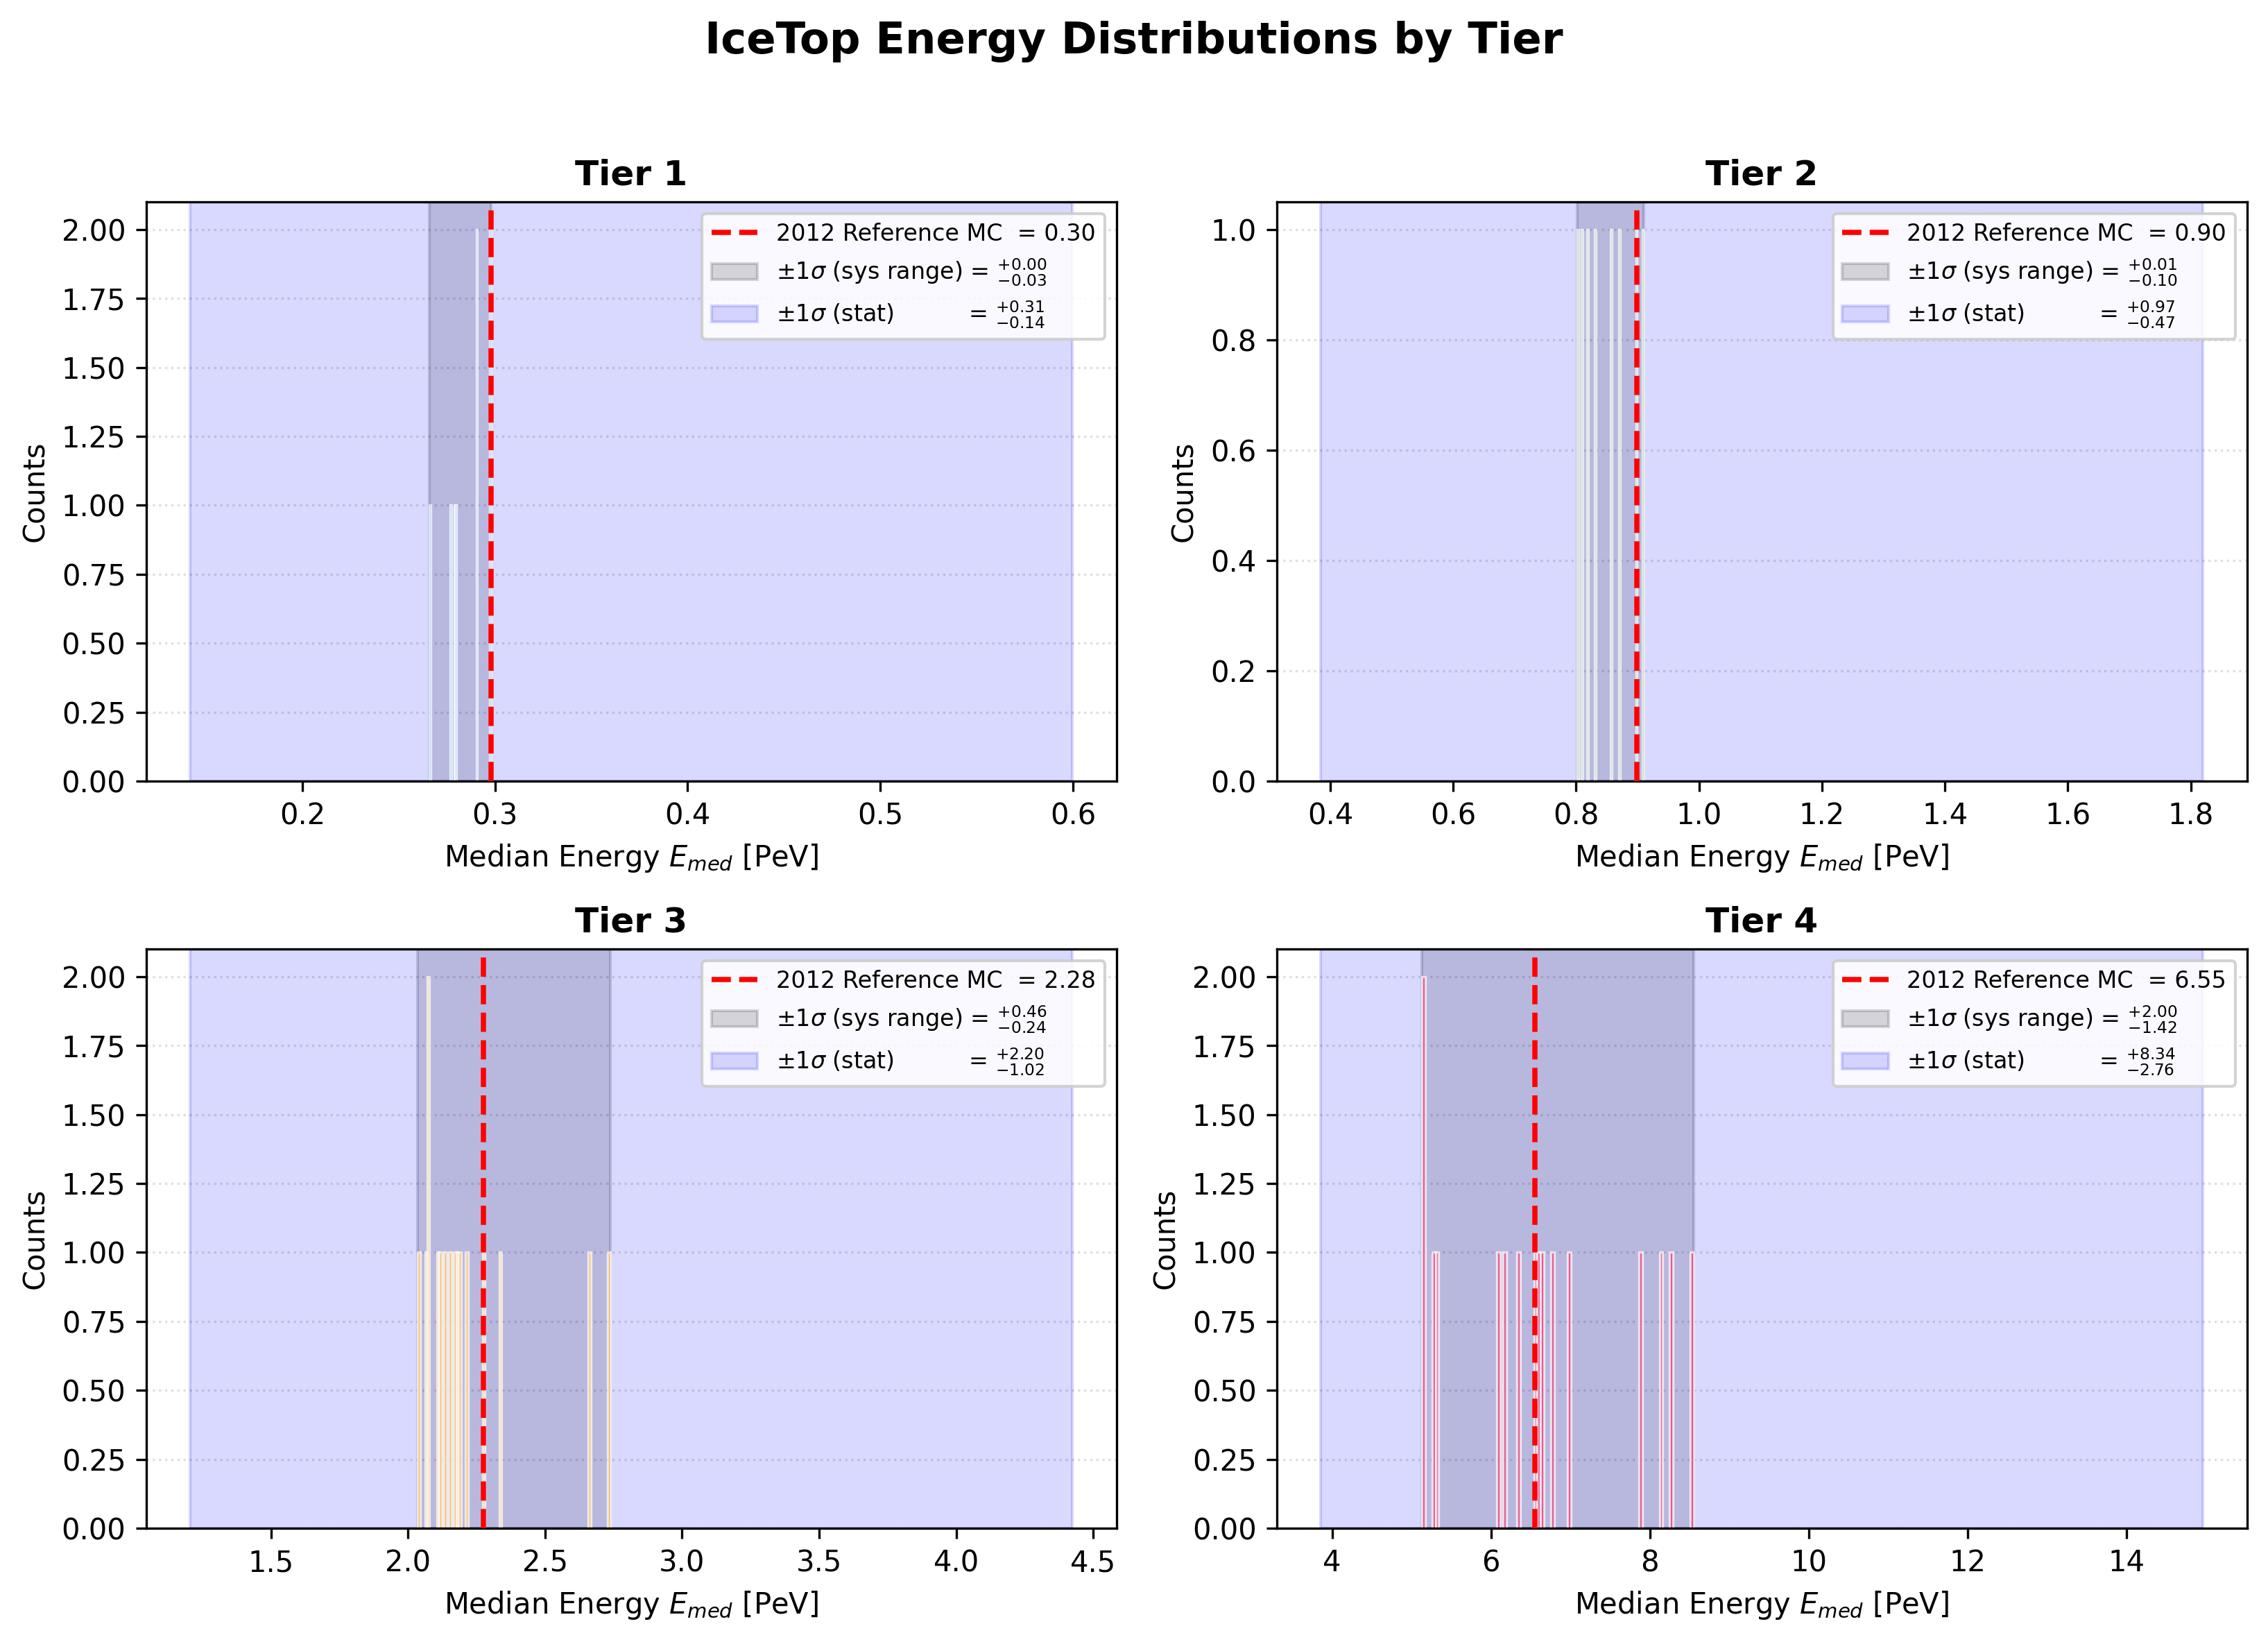

In [11]:
Reference_Emed         = [ref_medians[tier][0] for tier in sorted(ref_medians.keys())]
Reference_Emed_ErrLow  = [ref_medians[tier][1] for tier in sorted(ref_medians.keys())]
Reference_Emed_ErrHigh = [ref_medians[tier][2] for tier in sorted(ref_medians.keys())]

tiers = [sys_values for tier, sys_values in median_dict.items()]
tier_labels = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=300)
fig.suptitle('IceTop Energy Distributions by Tier', fontsize=15, fontweight='bold', y=0.98)

axes_flat = axes.flatten()

for i, (data, label, color, ref, errlow, errhigh) in enumerate(zip(tiers, tier_labels, colors, Reference_Emed, Reference_Emed_ErrLow, Reference_Emed_ErrHigh)):

    ax = axes_flat[i]
    mean = np.mean(data)
    std  = np.std(data, ddof=1)
    delta = mean - ref
    delta_pct = (delta / ref) * 100

    syshigh = np.abs(np.max(data) - ref)
    syslow  = np.abs(ref - np.min(data))
    
    # Adaptive bin count
    nbins = 10*max(5, len(data) // 2)
    n, bins, patches = ax.hist(data, bins=nbins, color=color, alpha=0.72,
                               edgecolor='white', linewidth=0.8, zorder=2)

    # Mean line
    #ax.axvline(mean, color='black', linewidth=1.8, linestyle='-',  label=f'Mean = {mean:.2f}', zorder=4)
    # Reference line
    ax.axvline(ref,  color='red',   linewidth=1.8, linestyle='--', label=f'2012 Reference MC  = {ref:.2f}',  zorder=4)
    # ±1σ shading
    #ax.axvspan(mean - std, mean + std, alpha=0.15, color='black', zorder=1, label=f'±1σ (spread) = {std:.2f}')
    ax.axvspan(ref - syslow,  ref + syshigh,  alpha=0.15, color='black', zorder=1, label=r'$\pm1\sigma$ (sys range) = $_{-%.2f}^{+%.2f}$' % (syslow,syshigh))
    ax.axvspan(mean - errlow, mean + errhigh, alpha=0.15, color='blue',  zorder=1, label=r'$\pm1\sigma$ (stat)          = $_{-%.2f}^{+%.2f}$' % (errlow,errhigh))

    ax.set_title(label, fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('Median Energy $E_{med}$ [PeV]', fontsize=10)
    ax.set_ylabel('Counts', fontsize=10)
    ax.grid(axis='y', alpha=0.4, linestyle=':', zorder=0)
    ax.set_axisbelow(True)
    
    # Stats box
    # sign = '+' if delta >= 0 else ''
    # stats_text = (f'$\\bar{{x}}$ = {mean:.3f}\n'
    #               f'$\\sigma$  = {std:.3f}\n'
    #               f'$\\Delta$  = {sign}{delta:.3f} ({sign}{delta_pct:.1f}%)')
    # ax.text(0.97, 0.96, stats_text, transform=ax.transAxes,
    #         fontsize=9, verticalalignment='top', horizontalalignment='right',
    #         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
    #                   edgecolor=color, alpha=0.9, linewidth=1.5))

    ax.legend(fontsize=8, loc='best', framealpha=0.85)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Split-Sky

### Median Values and Statistical Uncertainties

In [12]:
year = 2012
model = 'SIBYLL2.1'

# Load in the SIBYLL2.1 particle sims - note that these will also be your variable names
KEYS = ['energy', 'particle_type', 'hits', 'reco_pass', 'showerplane_zen', 'laputop_zen', 'Hweights', 'Gweights']

for key in KEYS:
    sim_file = f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'
    with open(sim_file, 'rb') as file:
        globals()[key] = np.load(file)

# Cuts for different compositions
IT_COMPS = {
    'proton': particle_type == 2.21200000e+03,
    'helium': particle_type == 1.00002004e+09,
    'oxygen': particle_type == 1.00008016e+09,
    'iron'  : particle_type == 1.00026056e+09
}

# Directional reconstruction cuts
plane_cut   = (showerplane_zen < np.radians(55))
laputop_cut = (laputop_zen < np.radians(55))
reco_cut    = (reco_pass == 1)

# Energy tier cuts
offset = np.ceil((year - 2011)/2)
TIERS = {
    'Tier 1': (3 <= hits) * (hits < 5),
    'Tier 2': (5 <= hits) * (hits < 10 - offset),
    'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
    'Tier 4': (17 - offset <= hits)
}

# Weights
it_weights = Gweights

In [13]:
ref_medians = {'lo':{}, 'hi':{}}

for tier, tier_cut in TIERS.items():
    
    # Print Tier for table
    print(f'{tier:<20} {"lo":<20} {"hi":<20}')
    print('-------')
    
    for comp in ['proton','iron','all']:

        out_str = f'  {comp:<7}'

        if tier == 'Tier 1':
            combined_cut = tier_cut * plane_cut
            z_cut = (showerplane_zen <= np.radians(it_split))
        else:
            combined_cut = tier_cut * laputop_cut * reco_cut
            z_cut = (laputop_zen <= np.radians(it_split))

        if comp != 'all':
            combined_cut *= IT_COMPS[comp]

        z_dict = {'lo':combined_cut * z_cut, 'hi':combined_cut * ~z_cut}
        for key, cut in z_dict.items():
       
            # Print median energy and its first sigma
            median, sigl, sigr = weighted_quantiles(energy[cut], it_weights[cut], quantiles=[.5,.16,.84]) / 1e6
            out_str += f'   {median:.2f} -{(median-sigl):.2f} +{(sigr-median):.2f} PeV'
    
            # Save values for later reference
            if comp == 'all':
                ref_medians[key][tier] = [median, median-sigl, sigr-median]

        print(out_str)
        
    print()

Tier 1               lo                   hi                  
-------
  proton    0.26 -0.12 +0.23 PeV   0.37 -0.20 +0.47 PeV
  iron      0.36 -0.17 +0.34 PeV   0.76 -0.39 +0.81 PeV
  all       0.28 -0.13 +0.27 PeV   0.44 -0.25 +0.57 PeV

Tier 2               lo                   hi                  
-------
  proton    0.76 -0.39 +0.73 PeV   1.12 -0.58 +1.29 PeV
  iron      1.05 -0.47 +0.96 PeV   2.29 -1.13 +2.41 PeV
  all       0.83 -0.43 +0.79 PeV   1.41 -0.77 +1.56 PeV

Tier 3               lo                   hi                  
-------
  proton    1.90 -0.79 +1.61 PeV   2.65 -1.21 +2.53 PeV
  iron      2.57 -1.08 +2.43 PeV   5.19 -2.30 +5.68 PeV
  all       2.10 -0.91 +1.82 PeV   3.29 -1.56 +3.26 PeV

Tier 4               lo                   hi                  
-------
  proton    5.28 -2.00 +5.60 PeV   7.33 -3.06 +9.03 PeV
  iron      7.72 -3.44 +10.99 PeV   14.43 -7.09 +19.76 PeV
  all       6.01 -2.42 +6.93 PeV   9.19 -4.17 +12.19 PeV



### LaTeX table output

In [16]:
out_dict = {comp:'' for comp in ['proton','iron','all']}

for tier, tier_cut in TIERS.items():
    
    for comp in out_dict.keys():

        if tier == 'Tier 1':
            combined_cut = tier_cut * plane_cut
            z_cut = (showerplane_zen <= np.radians(it_split))
        else:
            combined_cut = tier_cut * laputop_cut * reco_cut
            z_cut = (laputop_zen <= np.radians(it_split))

        if comp != 'all':
            combined_cut *= IT_COMPS[comp]

        z_dict = {'lo':combined_cut * z_cut, 'hi':combined_cut * ~z_cut}
        
        for key, cut in z_dict.items():
            median, sigl, sigr = weighted_quantiles(energy[cut], it_weights[cut], quantiles=[.5,.16,.84]) / 1e6
            if comp == 'all':
                out_dict[comp] += f' & \\textbf{{{median:.2f}}}$_{{-{(median-sigl):.2f}}}^{{+{(sigr-median):.2f}}}$'
            else:
                out_dict[comp] += f' & ${median:.2f}_{{-{(median-sigl):.2f}}}^{{+{(sigr-median):.2f}}}$'

for comp, out_str in out_dict.items():
    print(f'{comp:<8} {out_str}')

proton    & $0.26_{-0.12}^{+0.23}$ & $0.37_{-0.20}^{+0.47}$ & $0.76_{-0.39}^{+0.73}$ & $1.12_{-0.58}^{+1.29}$ & $1.90_{-0.79}^{+1.61}$ & $2.65_{-1.21}^{+2.53}$ & $5.28_{-2.00}^{+5.60}$ & $7.33_{-3.06}^{+9.03}$
iron      & $0.36_{-0.17}^{+0.34}$ & $0.76_{-0.39}^{+0.81}$ & $1.05_{-0.47}^{+0.96}$ & $2.29_{-1.13}^{+2.41}$ & $2.57_{-1.08}^{+2.43}$ & $5.19_{-2.30}^{+5.68}$ & $7.72_{-3.44}^{+10.99}$ & $14.43_{-7.09}^{+19.76}$
all       & \textbf{0.28}$_{-0.13}^{+0.27}$ & \textbf{0.44}$_{-0.25}^{+0.57}$ & \textbf{0.83}$_{-0.43}^{+0.79}$ & \textbf{1.41}$_{-0.77}^{+1.56}$ & \textbf{2.10}$_{-0.91}^{+1.82}$ & \textbf{3.29}$_{-1.56}^{+3.26}$ & \textbf{6.01}$_{-2.42}^{+6.93}$ & \textbf{9.19}$_{-4.17}^{+12.19}$


### Systematic Uncertainties

In [19]:
SIMS = {
    'EPOS-LHC': [2012, 2018],
    'QGSJET-II-04': [2012, 2018],
    'SIBYLL2.1': [2012, 2015],
    'SIBYLL2.3': [2012],
    'SIBYLL2.3d': [2018]
}

In [20]:
# Store median values for energy in dictionary
median_dict = {zkey:{f'Tier {i}':[] for i in range(1,5)} for zkey in ['lo','hi']}

for model, year_list in SIMS.items():

    for year in year_list:

        # Load target simulation
        for key in KEYS:
            sim_file = f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'
            with open(sim_file, 'rb') as file:
                globals()[key] = np.load(file)

        # Weights
        WEIGHTS = {
            'GSF': Gweights,
            'H4a': Hweights
        }

        # Directional reconstruction cuts
        plane_cut   = (showerplane_zen < np.radians(55))
        laputop_cut = (laputop_zen < np.radians(55))
        reco_cut    = (reco_pass == 1)

        # Energy tier cuts
        offset = int(np.ceil((year - 2011)/2))
        TIERS = {
            'Tier 1': (3 <= hits) * (hits < 5),
            'Tier 2': (5 <= hits) * (hits < 10 - offset),
            'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
            'Tier 4': (17 - offset <= hits)}
        if year >= 2015:
            TIERS.pop('Tier 1', None)
            TIERS.pop('Tier 2', None)

        for tier, tier_cut in TIERS.items():

            if tier == 'Tier 1':
                combined_cut = tier_cut * plane_cut
                z_cut = (showerplane_zen <= np.radians(it_split))
            else:
                combined_cut = tier_cut * laputop_cut * reco_cut
                z_cut = (laputop_zen <= np.radians(it_split))

            z_dict = {'lo':combined_cut * z_cut, 'hi':combined_cut * ~z_cut}
            for key, cut in z_dict.items():
    
                for weight_name, it_weights in WEIGHTS.items():
                    
                    median_dict[key][tier] += [weighted_quantiles(energy[cut], it_weights[cut])[0] / 1e6]

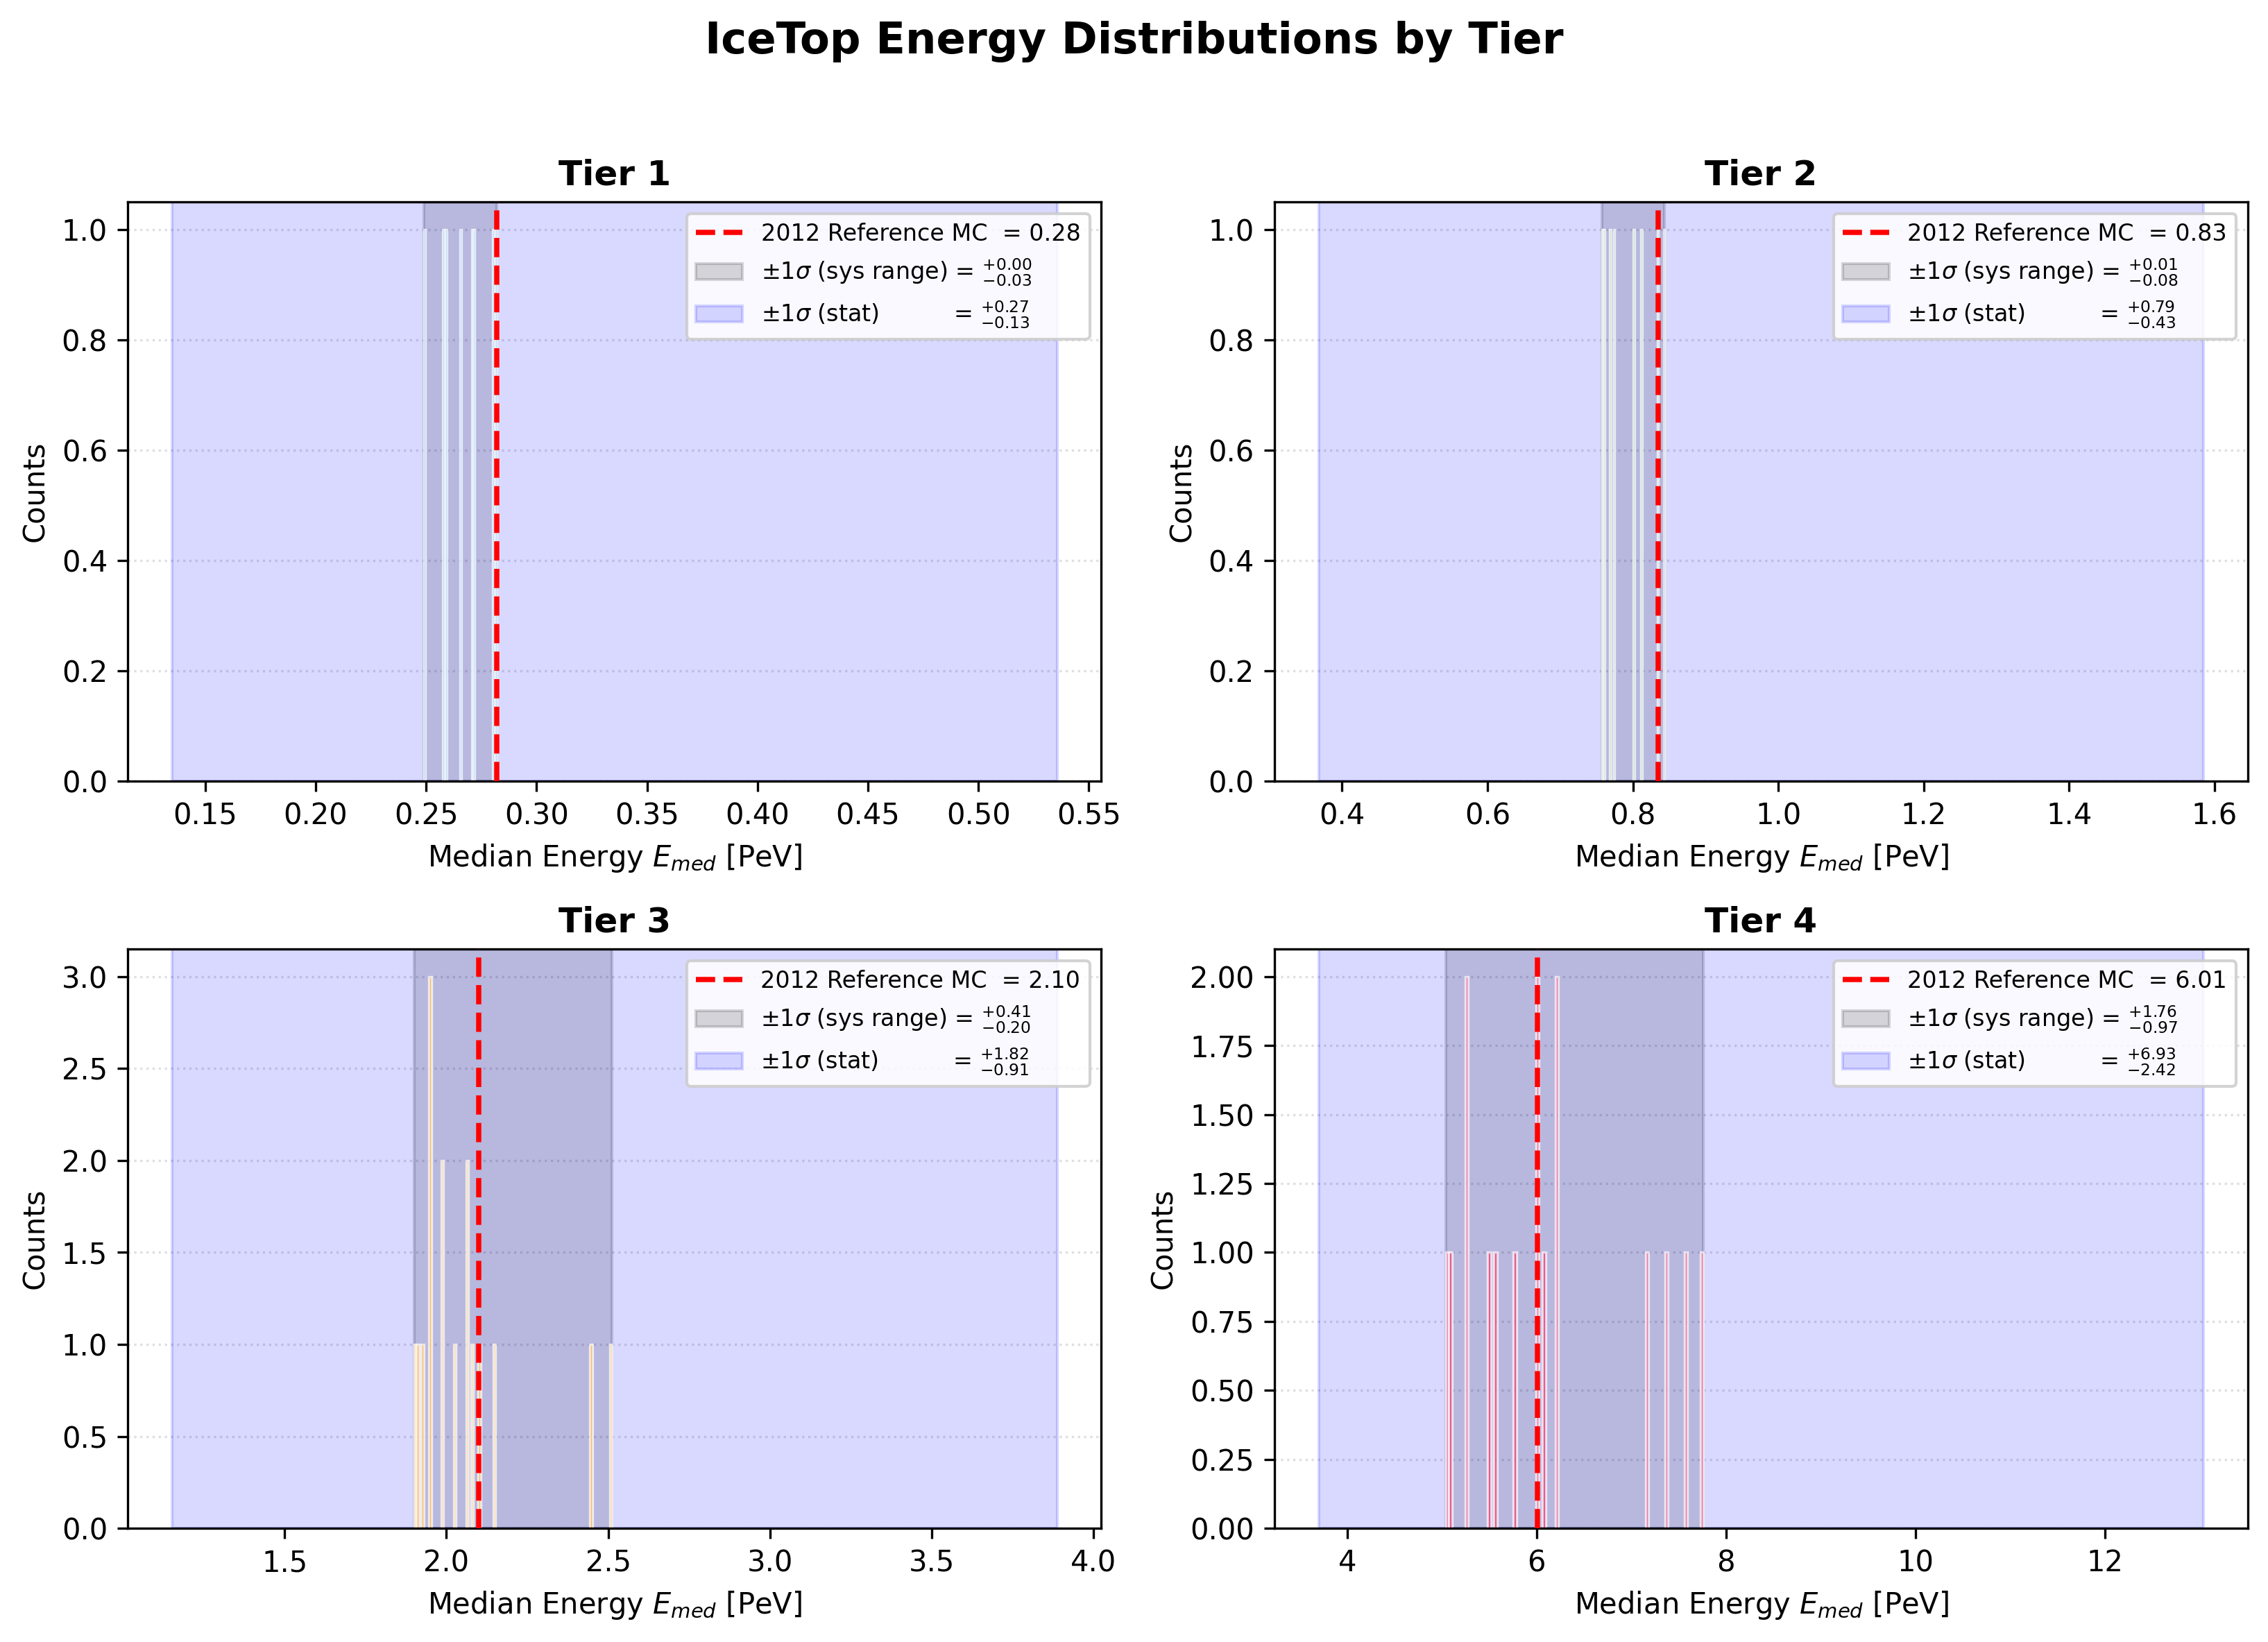

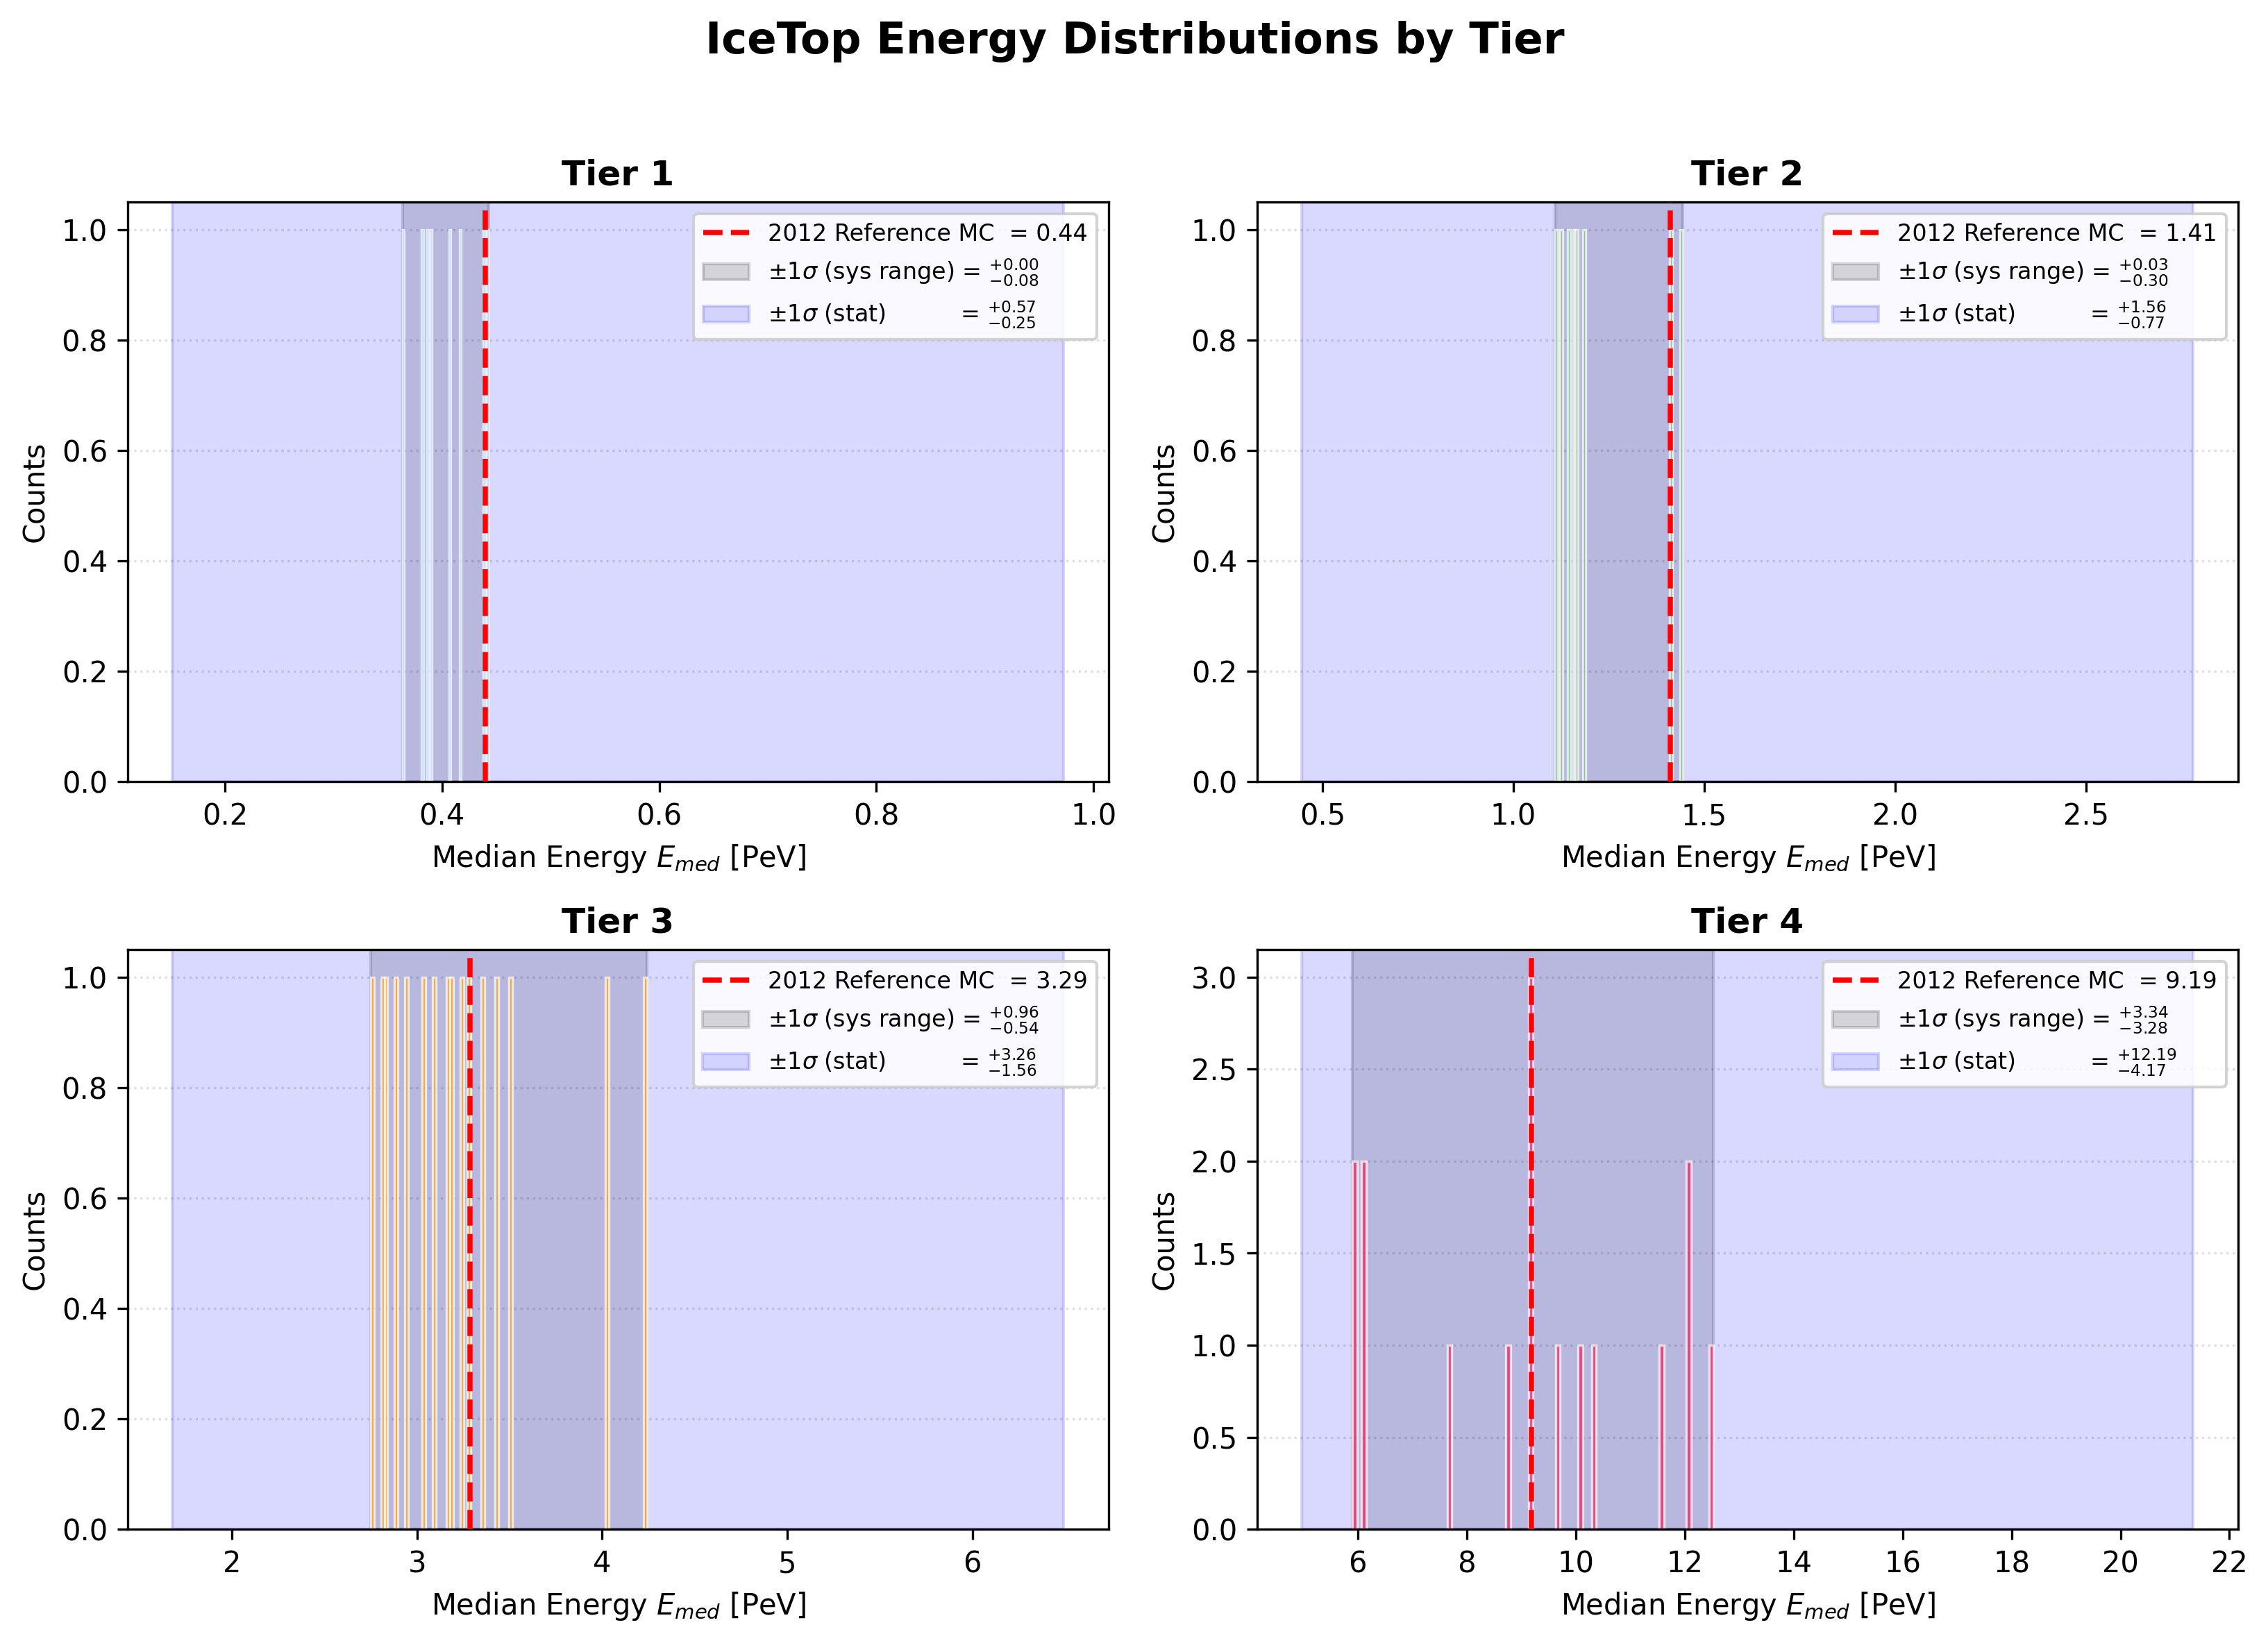

In [21]:
for zkey in median_dict.keys():

    Reference_Emed         = [ref_medians[zkey][tier][0] for tier in sorted(ref_medians[zkey].keys())]
    Reference_Emed_ErrLow  = [ref_medians[zkey][tier][1] for tier in sorted(ref_medians[zkey].keys())]
    Reference_Emed_ErrHigh = [ref_medians[zkey][tier][2] for tier in sorted(ref_medians[zkey].keys())]
    
    tiers = [sys_values for tier, sys_values in median_dict[zkey].items()]
    tier_labels = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=300)
    fig.suptitle('IceTop Energy Distributions by Tier', fontsize=15, fontweight='bold', y=0.98)
    
    axes_flat = axes.flatten()
    
    for i, (data, label, color, ref, errlow, errhigh) in enumerate(zip(tiers, tier_labels, colors, Reference_Emed, Reference_Emed_ErrLow, Reference_Emed_ErrHigh)):
    
        ax = axes_flat[i]
        mean = np.mean(data)
        std  = np.std(data, ddof=1)
        delta = mean - ref
        delta_pct = (delta / ref) * 100
    
        syshigh = np.abs(np.max(data) - ref)
        syslow  = np.abs(ref - np.min(data))
        
        # Adaptive bin count
        nbins = 10*max(5, len(data) // 2)
        n, bins, patches = ax.hist(data, bins=nbins, color=color, alpha=0.72,
                                   edgecolor='white', linewidth=0.8, zorder=2)
    
        # Mean line
        #ax.axvline(mean, color='black', linewidth=1.8, linestyle='-',  label=f'Mean = {mean:.2f}', zorder=4)
        # Reference line
        ax.axvline(ref,  color='red',   linewidth=1.8, linestyle='--', label=f'2012 Reference MC  = {ref:.2f}',  zorder=4)
        # ±1σ shading
        #ax.axvspan(mean - std, mean + std, alpha=0.15, color='black', zorder=1, label=f'±1σ (spread) = {std:.2f}')
        ax.axvspan(ref - syslow,  ref + syshigh,  alpha=0.15, color='black', zorder=1, label=r'$\pm1\sigma$ (sys range) = $_{-%.2f}^{+%.2f}$' % (syslow,syshigh))
        ax.axvspan(mean - errlow, mean + errhigh, alpha=0.15, color='blue',  zorder=1, label=r'$\pm1\sigma$ (stat)          = $_{-%.2f}^{+%.2f}$' % (errlow,errhigh))
    
        ax.set_title(label, fontsize=12, fontweight='bold', pad=6)
        ax.set_xlabel('Median Energy $E_{med}$ [PeV]', fontsize=10)
        ax.set_ylabel('Counts', fontsize=10)
        ax.grid(axis='y', alpha=0.4, linestyle=':', zorder=0)
        ax.set_axisbelow(True)
        
        # Stats box
        # sign = '+' if delta >= 0 else ''
        # stats_text = (f'$\\bar{{x}}$ = {mean:.3f}\n'
        #               f'$\\sigma$  = {std:.3f}\n'
        #               f'$\\Delta$  = {sign}{delta:.3f} ({sign}{delta_pct:.1f}%)')
        # ax.text(0.97, 0.96, stats_text, transform=ax.transAxes,
        #         fontsize=9, verticalalignment='top', horizontalalignment='right',
        #         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
        #                   edgecolor=color, alpha=0.9, linewidth=1.5))
    
        ax.legend(fontsize=8, loc='best', framealpha=0.85)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### LaTeX Table Output

In [28]:
#out_str = 'Mixed (sys)'
out_list = []

for zkey in ['lo','hi']:

    Reference_Emed = [ref_medians[zkey][tier][0] for tier in sorted(ref_medians[zkey].keys())]
    tiers = [sys_values for tier, sys_values in median_dict[zkey].items()]
    
    for data, ref in zip(tiers, Reference_Emed):
    
        syshigh = np.abs(np.max(data) - ref)
        syslow  = np.abs(ref - np.min(data))

        out_list += [f' & \\textbf{{{ref:.2f}}}$_{{-{syslow:.2f}}}^{{+{syshigh:.2f}}}$']

# Reorder from [Tier 1 lo, Tier 2 lo, ... Tier 1 hi, Tier 2 hi...] to [Tier 1 lo, Tier 1 hi, Tier 2 lo...]
half = len(out_list) // 2
first_half = out_list[:half]
second_half = out_list[half:]
reordered = [val for pair in zip(first_half, second_half) for val in pair]

out_str = ''.join(['Mixed (sys)'] + reordered)
print(out_str)

Mixed (sys) & \textbf{0.28}$_{-0.03}^{+0.00}$ & \textbf{0.44}$_{-0.08}^{+0.00}$ & \textbf{0.83}$_{-0.08}^{+0.01}$ & \textbf{1.41}$_{-0.30}^{+0.03}$ & \textbf{2.10}$_{-0.20}^{+0.41}$ & \textbf{3.29}$_{-0.54}^{+0.96}$ & \textbf{6.01}$_{-0.97}^{+1.76}$ & \textbf{9.19}$_{-3.28}^{+3.34}$
